# SMART-OM — Preprocessing for GLANCE (oral modality)

**Dataset:** [SMART-OM (Figshare)](https://figshare.com/articles/dataset/SMART-OM_A_SMARTphone_based_expert_annotated_dataset_of_Oral_Mucosa_images/31341790) — smartphone oral-mucosa photos with VIA (JSON) annotations.

**What this notebook produces:** one clean row per *unique photo*, one clean row per *annotation*, and review files for anything that could not be resolved automatically. **No train/val/test split is made here** — that is done in the merge notebook (with the other datasets), at patient level.

## Key findings this notebook handles

| Finding | How it is handled |
|---|---|
| The ~7.7k image files are **copies**: each photo appears as Unannotated + Region + Full (+ Lesion) copies | Only the **Unannotated** files are treated as photos; they are de-duplicated by **file hash (MD5)** |
| Some photos are filed under **two condition folders** (same bytes) | drop cross-class collisions |
| Region/Full/Lesion image copies have different sizes, and the old image-copy step overwrote files with the same name | **No image copies are made.** Outputs point to the original files |
| The old "clipping" used the wrong image size per name | Raw boxes are checked against the real photo size; only overflow ≤ 5 px is clipped, anything larger goes to a review file |
| Region / Full annotations mark **structures** (e.g. spatula, teeth, fingers, tongue), not only lesions | Every annotation has `stage` and an `is_lesion` flag (Lesion stage only) |
| Annotation filenames sometimes do not match photo names (typos) | Name normalisation + a small manual fix list; the rest are exported for review |
| Some Oral Cancer photos are named `Ca 1` ... `Ca 10` (no SMITA code) | Each `Ca N` is treated as its **own case** (`Ca1`, `Ca2`, ...). Before this fix they were all lumped into one `Unknown` patient, which would put 12 of 20 OCA photos in the same split |
| A few Normal photos receive lesion boxes from a lesion JSON filed under another condition (4 photos) | Links are kept (one JSON file covers several photos of a patient, so the folder can differ). These photos get `lesion_on_normal = True` so the merge notebook can keep them out of validation and test |
| Phone photos can carry EXIF rotation | Both raw and EXIF-corrected sizes are checked and the correct frame is recorded |

## Outputs (in `/kaggle/working`)

| File | Content |
|---|---|
| `smart_om_merge_ready.csv` | **Start here for the merge notebook.** One row per unique photo with standard columns: `label`, `patient_uid`, `eval_eligible`, `file_path`, `md5` |
| `smart_om_unique_photos.csv` | One row per unique photo with every detail column |
| `smart_om_annotations_final.csv` | One row per annotation, linked to `image_id` |
| `smart_om_label_conflicts.csv` | Photos filed under more than one condition |
| `smart_om_unmatched_annotations.csv` | Annotations that could not be linked to a photo |
| `smart_om_orphan_stage_images.csv` | Region/Full/Lesion images with no Unannotated copy |
| `smart_om_annotations_oob_review.csv` | Annotations overflowing the photo by more than 5 px (empty if none) |
| `smart_om_preprocessing_report.json` | All headline counts |

In [1]:
# [01] Imports and config
import os, re, json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from tqdm.auto import tqdm

# ------------------------------ CONFIG ------------------------------
ROOT_OVERRIDE = None          # e.g. '/kaggle/input/.../SMART-OM' if auto-detect fails
OUT = Path('/kaggle/working')
DATASET = 'smart_om'

UNANN = '01. Unannotated'
LESION_STAGE = '04. Lesion annotation'
SEVERITY = {'01. Normal': 0, '02. Variation from normal': 1, '03. OPMD': 2, '04. Oral Cancer': 3}
BOUNDS_TOL_PX = 5             # box overflow up to this many px is clipped; larger goes to a review file
MANUAL_STEM_FIX = {           # annotation-file name typos -> real photo name (logged as 'manual_fix')
    'SMITA00145_VT': 'SMITA00145_R_VT',
    'SMITA00025_R_LP': 'SMITA00025_R_LL',
}
SITE_CODES = {'DT': 'Dorsal tongue', 'VT': 'Ventral tongue', 'LB': 'Left buccal mucosa',
              'RB': 'Right buccal mucosa', 'UL': 'Upper lip', 'LL': 'Lower lip',
              'UA': 'Upper arch', 'LA': 'Lower arch'}
EXPECTED = {'image files': 7731, 'unique photos': 2442, 'patients': 329}   # 320 earlier counted all 'Ca N' photos as ONE 'Unknown' patient; 320 - 1 + 10 Ca cases = 329 (warnings only)

OUT.mkdir(parents=True, exist_ok=True)

In [2]:
# [02] Helpers and dataset root
def expect(name, got):
    flag = 'OK  ' if got == EXPECTED[name] else 'WARN'
    print(f'[{flag}] {name}: {got} (expected {EXPECTED[name]})')

def find_root():
    if ROOT_OVERRIDE:
        return Path(ROOT_OVERRIDE)
    for p in Path('/kaggle/input').rglob('SMART-OM'):
        if p.is_dir():
            return p
    raise FileNotFoundError("No 'SMART-OM' folder under /kaggle/input. Attach the dataset or set ROOT_OVERRIDE.")

ROOT = find_root()
print('Dataset root:', ROOT)

Dataset root: /kaggle/input/datasets/syedjaffarrazakazmi/smart-om/SMART-OM


## 1. Catalogue every image file (no pixels read yet)

Folder layout is `SMART-OM / <condition> / <annotation stage> / [<site>] / <image>`.
Condition and stage are read **relative to the dataset root**, so the position of the folders in the Kaggle path no longer matters.

In [3]:
# [03] Scan every image file
IMG_EXT = {'.jpg', '.jpeg', '.png'}
rows = []
for p in ROOT.rglob('*'):
    if p.is_file() and p.suffix.lower() in IMG_EXT:
        parts = p.relative_to(ROOT).parts            # (condition, stage, [site,] file)
        rows.append({
            'path': str(p),
            'rel_path': '/'.join(parts),
            'condition': parts[0],
            'stage': parts[1] if len(parts) >= 3 else None,
            'site_folder': re.sub(r'^\d+\.\s*', '', parts[2]) if len(parts) >= 4 else None,
            'file_name': p.name,
            'stem': p.stem,
        })
cat = pd.DataFrame(rows)

In [4]:
# [04] Check file counts and folder names
expect('image files', len(cat))
print('\nBy stage:\n', cat['stage'].value_counts(dropna=False).to_string())
print('\nBy condition:\n', cat['condition'].value_counts().to_string())

unknown = set(cat['condition']) - set(SEVERITY)
assert not unknown, f'Unexpected condition folders: {unknown}'
assert cat['stage'].notna().all(), 'Some images are not inside a stage folder'
assert UNANN in set(cat['stage']), 'No Unannotated folder found'

[OK  ] image files: 7731 (expected 7731)

By stage:
 stage
01. Unannotated          2469
03. Full annotation      2469
02. Region annotation    2469
04. Lesion annotation     324

By condition:
 condition
01. Normal                   6435
02. Variation from normal     716
03. OPMD                      500
04. Oral Cancer                80


## 2. Inspect the Unannotated photos

For each Unannotated file: **MD5 hash** (identifies identical photos), **size**, **EXIF orientation**, and a **full decode** (catches truncated files).
Patient ID, lighting type and oral site are read from the file name (site falls back to the folder name).

In [5]:
# [05] Hash and read size of every Unannotated photo
def inspect_image(path):
    md5 = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            md5.update(chunk)
    try:
        with Image.open(path) as im:
            w, h = im.size
            orient = int(im.getexif().get(0x0112, 1) or 1)
            im.load()                                   # full decode
        return md5.hexdigest(), w, h, orient, True
    except Exception:
        return md5.hexdigest(), np.nan, np.nan, 1, False

un = cat[cat['stage'] == UNANN].copy()
res = [inspect_image(p) for p in tqdm(un['path'], desc='hash + size')]
un = un.join(pd.DataFrame(res, index=un.index,
                          columns=['md5', 'width_raw', 'height_raw', 'exif_orientation', 'is_valid']))

hash + size:   0%|          | 0/2469 [00:00<?, ?it/s]

In [6]:
# [06] Drop unreadable files, EXIF-corrected size
print('Unannotated files :', len(un))
print('Unreadable files  :', int((~un['is_valid']).sum()))
print('EXIF orientation  :', un['exif_orientation'].value_counts().to_dict(), '(1 = normal; 5-8 swap width/height)')

un = un[un['is_valid']].copy()
un[['width_raw', 'height_raw']] = un[['width_raw', 'height_raw']].astype(int)
swap = un['exif_orientation'].isin([5, 6, 7, 8])
un['width_exif'] = np.where(swap, un['height_raw'], un['width_raw'])
un['height_exif'] = np.where(swap, un['width_raw'], un['height_raw'])

Unannotated files : 2469
Unreadable files  : 0
EXIF orientation  : {1: 2469} (1 = normal; 5-8 swap width/height)


In [7]:
# [07] Parse patient ID, lighting and oral site from the file name
# ---- fields parsed from the file name ----
def patient_of(stem):
    # SMITA00187 / SMITA00187-2 -> SMITA00187 | 'Ca 7', 'Ca3' -> Ca7, Ca3 (each Ca number = its own case) | 6026 -> 6026
    m = re.match(r'^(SMITA\d+|Ca\s*\d+|\d+)', stem, re.I)
    if not m:
        return 'Unknown'
    pid = re.sub(r'\s+', '', m.group(1))
    return 'Ca' + pid[2:] if pid.lower().startswith('ca') else pid

def capture_of(stem):
    m = re.search(r'[_-](W|R)(?=[_-])', stem)
    return {'W': 'White Light', 'R': 'Regular'}[m.group(1)] if m else 'Unknown'

def site_of(stem, folder):
    m = re.search(r'(?:^|[_\-\s])(DT|VT|LB|RB|UL|LL|UA|LA)\d*\s*$', stem, re.I)
    return SITE_CODES[m.group(1).upper()] if m else (folder or 'Other')

un['patient_id'] = un['stem'].map(patient_of)
un['capture_type'] = un['stem'].map(capture_of)
un['oral_site'] = [site_of(s, f) for s, f in zip(un['stem'], un['site_folder'])]

bad_pid = un.loc[un['patient_id'] == 'Unknown', 'stem']
if len(bad_pid):
    print('\nWARNING - patient ID not parsed for:', bad_pid.head(10).tolist())
else:
    print('\nAll patient IDs parsed. "Ca N" case IDs found:', int(un['patient_id'].str.match(r'^Ca\d+$').sum()), 'files')
print('\nCapture type :', un['capture_type'].value_counts().to_dict())
print('Oral site    :', un['oral_site'].value_counts().to_dict())
print('Files whose ID has a "-N" suffix (folded into the base patient ID):',
      int(un['stem'].str.match(r'^SMITA\d+-\d+').sum()))


All patient IDs parsed. "Ca N" case IDs found: 12 files

Capture type : {'Regular': 1990, 'White Light': 426, 'Unknown': 53}
Oral site    : {'Right buccal mucosa': 334, 'Left buccal mucosa': 330, 'Dorsal tongue': 327, 'Lower lip': 315, 'Ventral tongue': 310, 'Lower arch': 291, 'Upper arch': 287, 'Upper lip': 275}
Files whose ID has a "-N" suffix (folded into the base patient ID): 22


## 3. Collapse to unique photos

Identical files (same MD5) become **one photo**. If the same photo sits in more than one condition folder, the **most severe** label is kept
(OPMD > Variation from normal > Normal) and `label_conflict = True`.

In [8]:
# [08] Collapse identical files into unique photos
un['sev'] = un['condition'].map(SEVERITY)
un = un.sort_values(['sev', 'rel_path'], ascending=[False, True])      # most severe label first

photos = (un.groupby('md5')
            .agg(path=('path', 'first'), rel_path=('rel_path', 'first'), image_stem=('stem', 'first'),
                 patient_id=('patient_id', 'first'), n_patients=('patient_id', 'nunique'),
                 oral_site=('oral_site', 'first'), site_folder=('site_folder', 'first'),
                 capture_type=('capture_type', 'first'), exif_orientation=('exif_orientation', 'first'),
                 width_raw=('width_raw', 'first'), height_raw=('height_raw', 'first'),
                 width_exif=('width_exif', 'first'), height_exif=('height_exif', 'first'),
                 final_condition=('condition', 'first'),
                 all_conditions=('condition', lambda s: ' + '.join(sorted(set(s)))),
                 n_copies=('path', 'size'))
            .reset_index())
photos['label_conflict'] = photos['all_conditions'].str.contains(' + ', regex=False)
photos['image_id'] = DATASET + '_' + photos['md5'].str[:16]
photos['patient_uid'] = DATASET + '_' + photos['patient_id']
photos['source_dataset'] = DATASET

In [9]:
# [09] Count check and label conflicts
expect('unique photos', len(photos))
expect('patients', photos['patient_uid'].nunique())

print('\nLabel conflicts:', int(photos['label_conflict'].sum()))
print(photos.loc[photos['label_conflict'], 'all_conditions'].value_counts().to_string())
(photos.loc[photos['label_conflict'], ['image_id', 'patient_uid', 'image_stem', 'all_conditions', 'final_condition', 'rel_path']]
       .to_csv(OUT / 'smart_om_label_conflicts.csv', index=False))

[OK  ] unique photos: 2442 (expected 2442)
[OK  ] patients: 329 (expected 329)

Label conflicts: 27
all_conditions
01. Normal + 03. OPMD                     16
01. Normal + 02. Variation from normal    10
02. Variation from normal + 03. OPMD       1


In [10]:
# [10] Class table and site check
print('\nPhotos / patients per class:')
print(photos.groupby('final_condition').agg(photos=('image_id', 'size'), patients=('patient_uid', 'nunique')).to_string())

print('\nOral site vs folder name (check the mapping looks sensible):')
print(pd.crosstab(photos['oral_site'], photos['site_folder'].fillna('(none)')).to_string())


Photos / patients per class:
                           photos  patients
final_condition                            
01. Normal                   2119       306
02. Variation from normal     178       110
03. OPMD                      125        64
04. Oral Cancer                20        18

Oral site vs folder name (check the mapping looks sensible):
site_folder          Dorsal tongue  Left buccal mucosa  Lower arch  Lower lip  Right buccal mucosa  Upper arch  Upper lip  Ventral tongue
oral_site                                                                                                                                
Dorsal tongue                  321                   0           0          0                    0           0          0               0
Left buccal mucosa               0                 322           0          0                    0           0          0               0
Lower arch                       0                   0         291          0               

## 4. Parse the VIA annotation JSON files

Every drawn shape becomes one row with its **stage** (Region / Full / Lesion), **bounding box** and **raw points**.
Unlike the first version this also handles: empty / `null` JSON files, rectangles stored as `x, y, width, height`, and circles/ellipses stored as centre + radius.

In [11]:
# [11] Shape geometry helper
def shape_geometry(sh):
    xs, ys = sh.get('all_points_x'), sh.get('all_points_y')
    if xs and ys:
        return min(xs), min(ys), max(xs), max(ys), list(xs), list(ys)
    try:
        name = sh.get('name')
        if name == 'rect':
            x, y, w, h = sh['x'], sh['y'], sh['width'], sh['height']
            return x, y, x + w, y + h, [x, x + w, x + w, x], [y, y, y + h, y + h]
        if name == 'circle':
            cx, cy, r = sh['cx'], sh['cy'], sh['r']
            return cx - r, cy - r, cx + r, cy + r, [], []
        if name == 'ellipse':                                      # rotation ignored (bbox is approximate)
            cx, cy, rx, ry = sh['cx'], sh['cy'], sh['rx'], sh['ry']
            return cx - rx, cy - ry, cx + rx, cy + ry, [], []
    except KeyError:
        pass
    return None

In [12]:
# [12] Read every VIA JSON file
ann_rows, json_problems = [], []
json_files = sorted(ROOT.rglob('*.json'))
for jp in tqdm(json_files, desc='JSON'):
    parts = jp.relative_to(ROOT).parts
    cond, stage = parts[0], (parts[1] if len(parts) >= 3 else None)
    try:
        with open(jp, encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        json_problems.append((jp.name, f'unreadable: {e}')); continue
    meta = data.get('_via_img_metadata') if isinstance(data, dict) else None
    if not meta:
        json_problems.append((jp.name, 'empty file / no image metadata')); continue
    for entry in meta.values():
        if not isinstance(entry, dict):
            continue
        fname = entry.get('filename') or ''
        stem = Path(fname).stem if fname else re.sub(r'_(lesion|region|full)$', '', jp.stem, flags=re.I)
        regions = entry.get('regions') or []
        if isinstance(regions, dict):
            regions = list(regions.values())
        for r in regions:
            sh = (r or {}).get('shape_attributes') or {}
            g = shape_geometry(sh)
            if g is None:
                json_problems.append((jp.name, f"no usable geometry ('{sh.get('name')}') in {stem}")); continue
            xmin, ymin, xmax, ymax, xs, ys = g
            ann_rows.append({'json_file': jp.name, 'src_condition': cond, 'stage': stage, 'stem': stem,
                             'shape_type': sh.get('name', 'unknown'), 'num_points': len(xs),
                             'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
                             'points_x': xs, 'points_y': ys})

JSON:   0%|          | 0/1058 [00:00<?, ?it/s]

In [13]:
# [13] Annotation table and summary
ann = pd.DataFrame(ann_rows)
n_raw = len(ann)
print('JSON files        :', len(json_files))
print('Annotations parsed:', n_raw, '(first version found 37,943)')
print('\nBy stage:\n', ann['stage'].value_counts(dropna=False).to_string())
print('\nBy shape:\n', ann['shape_type'].value_counts().to_string())
print(f'\nJSON files with problems: {len(json_problems)}')
for name, why in json_problems[:15]:
    print('  -', name, '->', why)

JSON files        : 1058
Annotations parsed: 38005 (first version found 37,943)

By stage:
 stage
03. Full annotation      26611
02. Region annotation    10986
04. Lesion annotation      408

By shape:
 shape_type
polygon     22011
rect        15136
polyline      488
ellipse       284
circle         86

JSON files with problems: 5
  - SMITA00028_R_region.json -> no usable geometry ('None') in SMITA00028_R_VT
  - SMITA00333_R_region.json -> empty file / no image metadata
  - SMITA00028_R_full.json -> no usable geometry ('None') in SMITA00028_R_VT
  - SMITA00212_R_full.json -> no usable geometry ('None') in SMITA00212_R_LB1
  - SMITA00212_R_full.json -> no usable geometry ('None') in SMITA00212_R_LB1


## 5. Link annotations to photos

Each annotation is linked to a photo by **hash**, using this order:

1. **`condition+stem`** – same name inside the same condition folder (resolves photos that share a name across conditions)
2. **`stem_only`** – name is unique across the whole dataset
3. **`manual_fix`** – known typos (`MANUAL_STEM_FIX`), plus double underscores (`R__LL` → `R_LL`) are normalised everywhere

Exact duplicate annotations (same photo, stage and geometry – e.g. the same JSON stored under two condition folders) are then removed.
Anything unlinked is exported for review rather than guessed.

In [14]:
# [14] Name lookup tables
norm = lambda s: re.sub(r'_+', '_', str(s).strip())

un['key'] = un['stem'].map(norm)
cond_md5 = un.groupby(['condition', 'key'])['md5'].agg(lambda s: sorted(set(s)))
stem_md5 = un.groupby('key')['md5'].agg(lambda s: sorted(set(s)))
cond_map = {k: v[0] for k, v in cond_md5.items() if len(v) == 1}
ambiguous = {k for k, v in cond_md5.items() if len(v) > 1}
stem_map = {k: v[0] for k, v in stem_md5.items() if len(v) == 1}
print('Names that point to 2+ different photos inside one condition folder:', len(ambiguous))
print('Names shared by 2+ different photos across conditions (resolved by condition):',
      int((stem_md5.map(len) > 1).sum()))

Names that point to 2+ different photos inside one condition folder: 2
Names shared by 2+ different photos across conditions (resolved by condition): 4


In [15]:
# [15] Linking rules (condition+stem, stem_only, manual_fix)
def link(cond, stem):
    k = norm(stem)
    if (cond, k) in cond_map:
        return cond_map[(cond, k)], 'condition+stem'
    if (cond, k) in ambiguous:
        return None, 'ambiguous_name'
    if k in stem_map:
        return stem_map[k], 'stem_only'
    if stem in MANUAL_STEM_FIX:
        k2 = norm(MANUAL_STEM_FIX[stem])
        if (cond, k2) in cond_map:
            return cond_map[(cond, k2)], 'manual_fix'
        if k2 in stem_map:
            return stem_map[k2], 'manual_fix'
    return None, 'no_photo_found'

In [16]:
# [16] Link every annotation to a photo hash
pairs = ann[['src_condition', 'stem']].drop_duplicates().reset_index(drop=True)
res = [link(c, s) for c, s in zip(pairs['src_condition'], pairs['stem'])]
pairs['md5'] = [r[0] for r in res]
pairs['match_method'] = [r[1] for r in res]
ann = ann.merge(pairs, on=['src_condition', 'stem'], how='left')

print('\nMatch method:\n', ann['match_method'].value_counts().to_string())


Match method:
 match_method
condition+stem    23270
stem_only         14604
no_photo_found       91
ambiguous_name       25
manual_fix           15


In [17]:
# [17] Export unmatched annotations
# ---- unmatched annotations (exported, not guessed) ----
unmatched = ann[ann['md5'].isna()]
n_unmatched = len(unmatched)
unmatched.drop(columns=['points_x', 'points_y']).to_csv(OUT / 'smart_om_unmatched_annotations.csv', index=False)
print(f'\nUnmatched annotations: {n_unmatched} across {unmatched["stem"].nunique()} names -> smart_om_unmatched_annotations.csv')
print(unmatched.groupby(['stem', 'match_method']).size().head(20).to_string())


Unmatched annotations: 116 across 10 names -> smart_om_unmatched_annotations.csv
stem              match_method  
8 - RB            no_photo_found    20
Ca 2              ambiguous_name    11
Ca 4              ambiguous_name    14
SMITA00044_R_R    no_photo_found     9
SMITA00087_R_LB   no_photo_found    10
SMITA00087_R_RB   no_photo_found    17
SMITA00104_R_     no_photo_found     3
SMITA00131_R_LB   no_photo_found    25
SMITA00167_R_LL3  no_photo_found     1
SMITA00212_R_LB   no_photo_found     6


In [18]:
# [18] Export stage-copy images with no Unannotated photo
# ---- stage-copy images that have no Unannotated photo ----
others = cat[cat['stage'] != UNANN].copy()
others['key'] = others['stem'].map(norm)
has_photo = [((c, k) in cond_map) or ((c, k) in ambiguous) or (k in stem_map)
             for c, k in zip(others['condition'], others['key'])]
orphans = others[~np.array(has_photo)]
orphans[['condition', 'stage', 'stem', 'rel_path']].to_csv(OUT / 'smart_om_orphan_stage_images.csv', index=False)
print(f'\nStage-copy images with no Unannotated photo: {len(orphans)} ({orphans["stem"].nunique()} names) -> smart_om_orphan_stage_images.csv')
print(orphans.groupby(['condition', 'stage']).size().to_string() if len(orphans) else '  none')


Stage-copy images with no Unannotated photo: 41 (38 names) -> smart_om_orphan_stage_images.csv
condition                  stage                
01. Normal                 02. Region annotation     3
                           03. Full annotation       1
02. Variation from normal  04. Lesion annotation     2
03. OPMD                   02. Region annotation     3
                           03. Full annotation       1
                           04. Lesion annotation     1
04. Oral Cancer            02. Region annotation    10
                           03. Full annotation      10
                           04. Lesion annotation    10


In [19]:
# [19] Remove exact duplicate annotations and attach photo info
# ---- remove exact duplicates ----
linked = ann[ann['md5'].notna()].copy()
linked['geom_key'] = (linked['shape_type'] + '|'
                      + linked[['xmin', 'ymin', 'xmax', 'ymax']].astype(str).agg('|'.join, axis=1) + '|'
                      + linked['points_x'].map(lambda l: ','.join(map(str, l))) + '|'
                      + linked['points_y'].map(lambda l: ','.join(map(str, l))))
dup_mask = linked.duplicated(['md5', 'stage', 'geom_key'])
n_dups = int(dup_mask.sum())
linked = linked[~dup_mask].copy()
print(f'\nExact duplicate annotations removed: {n_dups}')

linked = linked.merge(photos[['md5', 'image_id', 'patient_uid', 'width_raw', 'height_raw', 'width_exif', 'height_exif']],
                      on='md5', how='left')
print('Annotations linked to photos:', len(linked))


Exact duplicate annotations removed: 9695
Annotations linked to photos: 28194


## 6. Bounds check against the real photo size

Boxes are checked against the **photo they belong to** (not a per-name size). Two frames are tested – raw pixel size and EXIF-corrected size – and the one with fewer violations is recorded as `annotation_frame`.
Overflow up to `BOUNDS_TOL_PX` is clipped (box and points); larger overflow is **not** clipped silently – it goes to a review file.

In [20]:
# [20] Overflow check and annotation frame
def max_overflow(df, wcol, hcol):
    return np.maximum.reduce([(-df['xmin']).to_numpy(float), (-df['ymin']).to_numpy(float),
                              (df['xmax'] - df[wcol]).to_numpy(float), (df['ymax'] - df[hcol]).to_numpy(float),
                              np.zeros(len(df))])

ov_raw = max_overflow(linked, 'width_raw', 'height_raw')
ov_exif = max_overflow(linked, 'width_exif', 'height_exif')
print(pd.DataFrame({'any overflow (>0 px)': [(ov_raw > 0).sum(), (ov_exif > 0).sum()],
                    f'> {BOUNDS_TOL_PX} px': [(ov_raw > BOUNDS_TOL_PX).sum(), (ov_exif > BOUNDS_TOL_PX).sum()]},
                   index=['raw size', 'EXIF-corrected size']).to_string())

FRAME = 'raw' if (ov_raw > 0).sum() <= (ov_exif > 0).sum() else 'exif'
print('\nAnnotation frame used:', FRAME)

photos['annotation_frame'] = FRAME
photos['width'] = photos[f'width_{FRAME}']
photos['height'] = photos[f'height_{FRAME}']
linked['img_width'] = linked[f'width_{FRAME}']
linked['img_height'] = linked[f'height_{FRAME}']
linked['overflow_px'] = ov_raw if FRAME == 'raw' else ov_exif

                     any overflow (>0 px)  > 5 px
raw size                              300      94
EXIF-corrected size                   300      94

Annotation frame used: raw


In [21]:
# [21] Exclude large overflow, clip small overflow
too_far = linked['overflow_px'] > BOUNDS_TOL_PX
n_oob_dropped = int(too_far.sum())
linked[too_far].drop(columns=['points_x', 'points_y']).to_csv(OUT / 'smart_om_annotations_oob_review.csv', index=False)
linked = linked[~too_far].copy()

clip_mask = (linked['overflow_px'] > 0).to_numpy()
linked['was_clipped'] = clip_mask
linked['xmin'] = linked['xmin'].clip(lower=0)
linked['ymin'] = linked['ymin'].clip(lower=0)
linked['xmax'] = np.minimum(linked['xmax'], linked['img_width'])
linked['ymax'] = np.minimum(linked['ymax'], linked['img_height'])

def _clip(vals, hi):
    return [min(max(v, 0), hi) for v in vals]
linked['points_x'] = [(_clip(p, w) if c else p) for p, w, c in zip(linked['points_x'], linked['img_width'], clip_mask)]
linked['points_y'] = [(_clip(p, h) if c else p) for p, h, c in zip(linked['points_y'], linked['img_height'], clip_mask)]

In [22]:
# [22] Box sizes and lesion flag
linked['bbox_width'] = linked['xmax'] - linked['xmin']
linked['bbox_height'] = linked['ymax'] - linked['ymin']
linked['bbox_degenerate'] = (linked['bbox_width'] <= 0) | (linked['bbox_height'] <= 0)
linked['is_lesion'] = linked['stage'].eq(LESION_STAGE)

print(f'Excluded (overflow > {BOUNDS_TOL_PX} px): {n_oob_dropped}')
print(f'Clipped (overflow 1-{BOUNDS_TOL_PX} px) : {int(clip_mask.sum())}')
print(f'Zero-area boxes (kept, flagged)  : {int(linked["bbox_degenerate"].sum())}')

Excluded (overflow > 5 px): 94
Clipped (overflow 1-5 px) : 206
Zero-area boxes (kept, flagged)  : 0


## 7. Visual check

Red = **lesion** annotations, blue = **Region/Full** annotations, drawn on the original photo.
Look for: boxes landing on the right structures, and that Region/Full boxes are *not* all lesions.

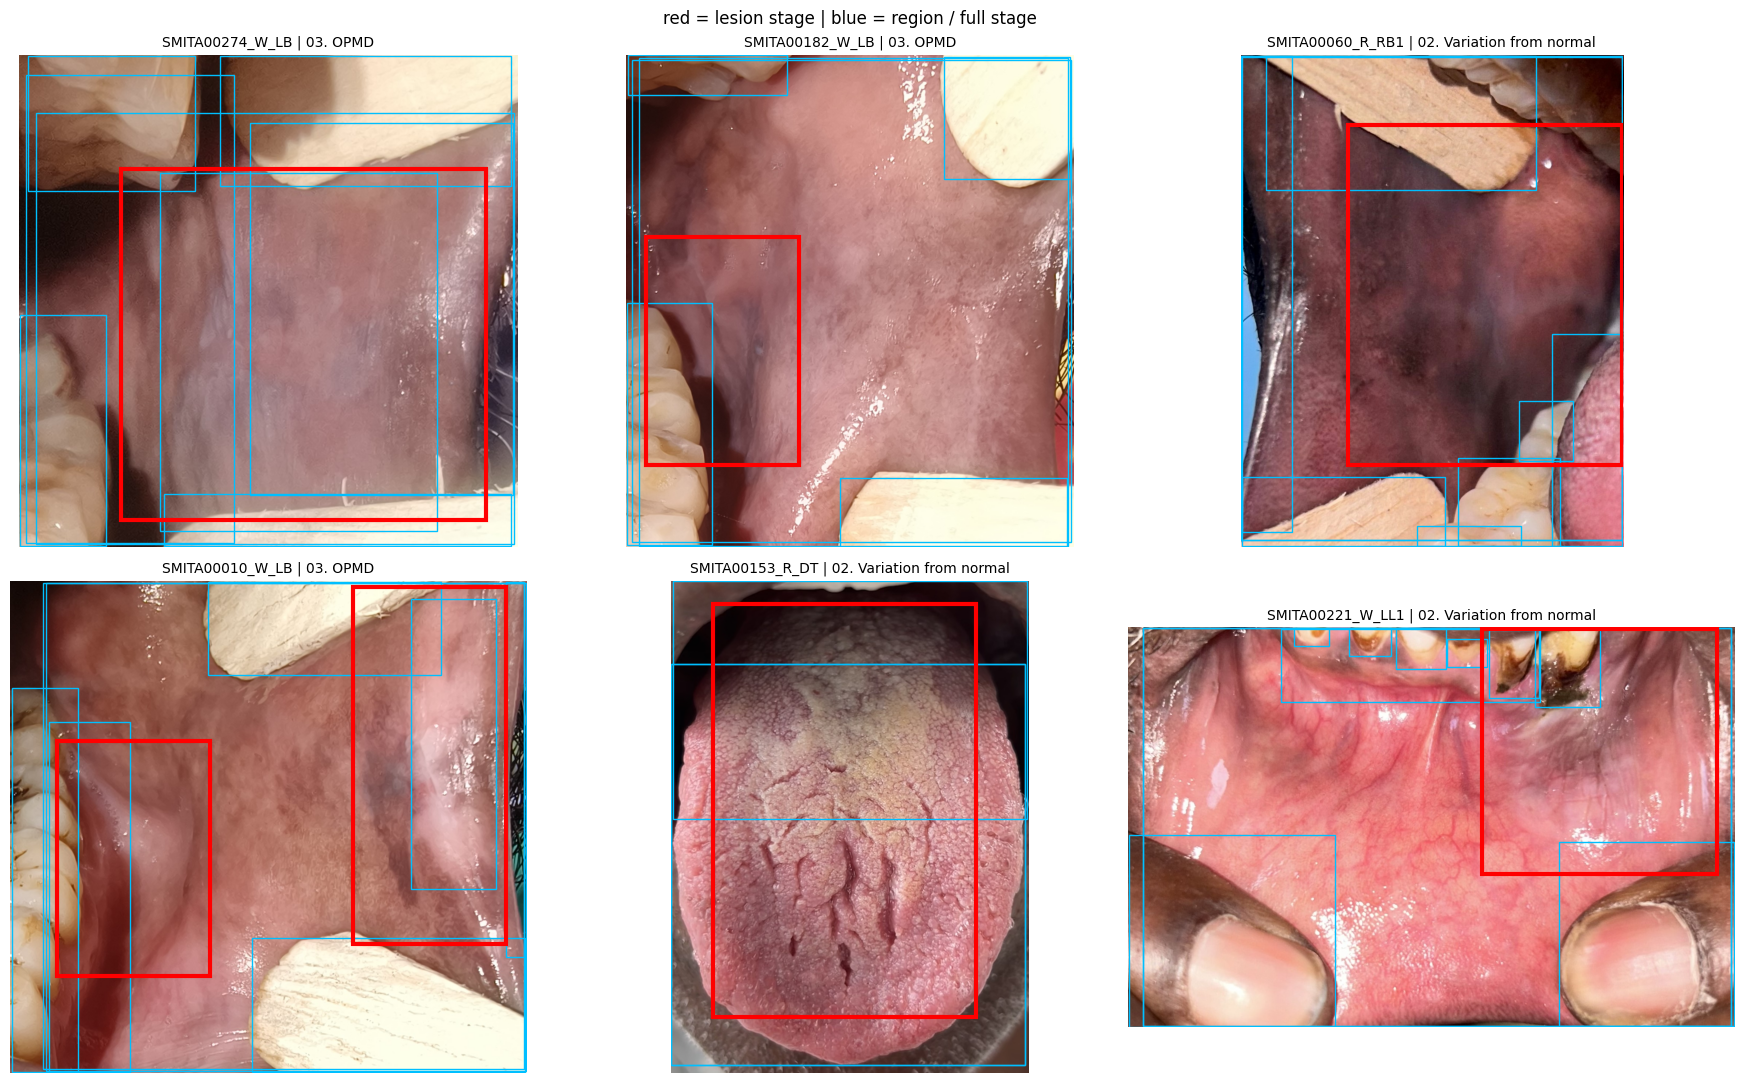

In [23]:
# [23] Visual check
import matplotlib.pyplot as plt
import matplotlib.patches as patches

with_lesion = linked.loc[linked['is_lesion'], 'image_id'].unique()
pick = photos[photos['image_id'].isin(with_lesion)]
pick = pick.sample(min(6, len(pick)), random_state=0) if len(pick) else pick

if len(pick):
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.ravel()
    for ax in axes:
        ax.axis('off')
    for ax, (_, r) in zip(axes, pick.iterrows()):
        im = Image.open(r['path'])
        if FRAME == 'exif':
            im = ImageOps.exif_transpose(im)
        ax.imshow(im)
        ax.set_title(f"{r['image_stem']} | {r['final_condition']}", fontsize=10)
        for _, a in linked[linked['image_id'] == r['image_id']].iterrows():
            col, lw = ('red', 3) if a['is_lesion'] else ('deepskyblue', 1)
            ax.add_patch(patches.Rectangle((a['xmin'], a['ymin']), a['bbox_width'], a['bbox_height'],
                                           fill=False, edgecolor=col, linewidth=lw))
    plt.suptitle('red = lesion stage | blue = region / full stage', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No photos with lesion annotations to display.')

## 8. Finalise, validate and export

All checks are evaluated and printed **after** the files are written; the notebook raises an error at the end if any critical check fails.

In [24]:
# [24] Final annotation table and per-photo flags
final_ann = linked.copy()
final_ann['source_dataset'] = DATASET
final_ann = final_ann.sort_values(['image_id', 'stage']).reset_index(drop=True)
final_ann['annotation_id'] = (final_ann['image_id'] + '_' + final_ann['stage'].str[:2] + '_'
                              + final_ann.groupby(['image_id', 'stage']).cumcount().astype(str))

# per-photo annotation counts
for stage, col in {'02. Region annotation': 'n_region_ann', '03. Full annotation': 'n_full_ann',
                   LESION_STAGE: 'n_lesion_ann'}.items():
    photos[col] = photos['image_id'].map(final_ann[final_ann['stage'] == stage].groupby('image_id').size()).fillna(0).astype(int)
photos['has_lesion_annotation'] = photos['n_lesion_ann'] > 0
# Normal photo that carries a lesion box: label or annotation is inconsistent, review before using it for evaluation
photos['lesion_on_normal'] = (photos['final_condition'] == '01. Normal') & photos['has_lesion_annotation']

In [25]:
# [25] Write photo and annotation CSVs
# ---------------- export ----------------
photo_cols = ['image_id', 'source_dataset', 'patient_uid', 'patient_id', 'image_stem', 'file_path', 'rel_path',
              'oral_site', 'site_folder', 'capture_type', 'final_condition', 'all_conditions', 'label_conflict',
              'n_copies', 'width', 'height', 'width_raw', 'height_raw', 'exif_orientation', 'annotation_frame',
              'n_region_ann', 'n_full_ann', 'n_lesion_ann', 'has_lesion_annotation', 'lesion_on_normal', 'md5']
photos_out = photos.rename(columns={'path': 'file_path'})[photo_cols]
photos_out.to_csv(OUT / 'smart_om_unique_photos.csv', index=False)

ann_out = final_ann.copy()
ann_out['points_x'] = ann_out['points_x'].map(json.dumps)
ann_out['points_y'] = ann_out['points_y'].map(json.dumps)
ann_cols = ['annotation_id', 'image_id', 'patient_uid', 'source_dataset', 'stage', 'is_lesion', 'shape_type',
            'num_points', 'xmin', 'ymin', 'xmax', 'ymax', 'bbox_width', 'bbox_height', 'img_width', 'img_height',
            'points_x', 'points_y', 'was_clipped', 'bbox_degenerate', 'src_condition', 'json_file', 'match_method']
ann_out[ann_cols].to_csv(OUT / 'smart_om_annotations_final.csv', index=False)

In [26]:
# [26] Reconciliation and class table
# ---------------- reconciliation ----------------
print('ANNOTATION RECONCILIATION')
print(f'  parsed from JSON                 : {n_raw}')
print(f'  - not linked to a photo          : {n_unmatched}')
print(f'  - exact duplicates               : {n_dups}')
print(f'  - overflow > {BOUNDS_TOL_PX} px (review file)    : {n_oob_dropped}')
print(f'  = final annotations              : {len(final_ann)}')
print('\nFinal annotations by stage:\n', final_ann['stage'].value_counts().to_string())

print('\nFINAL CLASS TABLE (one row per unique photo)')
summary = (photos.groupby('final_condition')
                 .agg(photos=('image_id', 'size'), patients=('patient_uid', 'nunique'),
                      with_lesion_annotation=('has_lesion_annotation', 'sum'))
                 .reset_index())
print(summary.to_string(index=False))

ANNOTATION RECONCILIATION
  parsed from JSON                 : 38005
  - not linked to a photo          : 116
  - exact duplicates               : 9695
  - overflow > 5 px (review file)    : 94
  = final annotations              : 28100

Final annotations by stage:
 stage
03. Full annotation      19794
02. Region annotation     7909
04. Lesion annotation      397

FINAL CLASS TABLE (one row per unique photo)
          final_condition  photos  patients  with_lesion_annotation
               01. Normal    2119       306                       4
02. Variation from normal     178       110                     171
                 03. OPMD     125        64                     124
          04. Oral Cancer      20        18                      16


In [27]:
# [27] Run all checks
# ---------------- checks ----------------
checks = [
    ('image_id is unique',                          photos['image_id'].is_unique),
    ('md5 is unique',                               photos['md5'].is_unique),
    ('every photo belongs to exactly one patient',  bool((photos['n_patients'] == 1).all())),
    ('no unparsed (Unknown) patient IDs',           bool((photos['patient_id'] != 'Unknown').all())),
    ('every photo file exists',                     bool(photos['path'].map(os.path.exists).all())),
    ('annotation_id is unique',                     final_ann['annotation_id'].is_unique),
    ('every annotation links to a photo',           bool(final_ann['image_id'].isin(photos['image_id']).all())),
    ('no duplicate annotations',                    not final_ann.duplicated(['image_id', 'stage', 'geom_key']).any()),
    ('all boxes inside the photo',                  bool(((final_ann['xmin'] >= 0) & (final_ann['ymin'] >= 0)
                                                          & (final_ann['xmax'] <= final_ann['img_width'])
                                                          & (final_ann['ymax'] <= final_ann['img_height'])).all())),
    ('annotation counts reconcile',                 n_raw - n_unmatched - n_dups - n_oob_dropped == len(final_ann)),
    ('every annotation has a stage',                bool(ann['stage'].notna().all())),
]
print('\nCHECKS')
for name, ok in checks:
    print(f'  [{"PASS" if ok else "FAIL"}] {name}')


CHECKS
  [PASS] image_id is unique
  [PASS] md5 is unique
  [PASS] every photo belongs to exactly one patient
  [PASS] no unparsed (Unknown) patient IDs
  [PASS] every photo file exists
  [PASS] annotation_id is unique
  [PASS] every annotation links to a photo
  [PASS] no duplicate annotations
  [PASS] all boxes inside the photo
  [PASS] annotation counts reconcile
  [PASS] every annotation has a stage


In [28]:
# [28] Write report and list output files
report = {
    'image_files': int(len(cat)), 'unique_photos': int(len(photos)), 'patients': int(photos['patient_uid'].nunique()),
    'label_conflicts': int(photos['label_conflict'].sum()),
    'annotations_parsed': int(n_raw), 'annotations_unmatched': int(n_unmatched), 'annotations_duplicates': int(n_dups),
    'annotations_oob_review': int(n_oob_dropped), 'annotations_final': int(len(final_ann)),
    'annotations_lesion': int(final_ann['is_lesion'].sum()), 'annotation_frame': FRAME,
    'orphan_stage_images': int(len(orphans)), 'json_problems': len(json_problems),
    'photos_per_class': photos['final_condition'].value_counts().to_dict(),
    'patients_per_class': photos.groupby('final_condition')['patient_uid'].nunique().to_dict(),
}
with open(OUT / 'smart_om_preprocessing_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('\nFiles written to', OUT)
for p in sorted(OUT.glob('smart_om_*')):
    print('  ', p.name)


Files written to /kaggle/working
   smart_om_annotations_final.csv
   smart_om_annotations_oob_review.csv
   smart_om_label_conflicts.csv
   smart_om_orphan_stage_images.csv
   smart_om_preprocessing_report.json
   smart_om_unique_photos.csv
   smart_om_unmatched_annotations.csv


In [29]:
# [29] Stop if any check failed
failed = [n for n, ok in checks if not ok]
assert not failed, f'Failed checks: {failed}'
print('\nAll checks passed.')


All checks passed.


## 9. Merge-ready file

One row per unique photo with the columns the merge notebook needs. `Variation` is kept as its own label until you decide how to map it. `eval_eligible` is False for photos with a label conflict or a lesion box on a Normal photo, so keep those out of validation and test.

In [30]:
# [30] Write smart_om_merge_ready.csv
LABEL_MAP = {'01. Normal': 'Healthy', '02. Variation from normal': 'Variation',
             '03. OPMD': 'OPMD', '04. Oral Cancer': 'OCA'}

merge_ready = pd.DataFrame({
    'image_id': photos['image_id'],
    'source': DATASET,
    'patient_uid': photos['patient_uid'],                       # group for patient-level splits
    'id_type': np.where(photos['patient_id'].str.match(r'^Ca\d+$'), 'assumed', 'real'),   # Ca N cases are assumed separate people
    'orig_label': photos['final_condition'],
    'label': photos['final_condition'].map(LABEL_MAP),
    'label_tier': 'clinical_attested',
    'label_conflict': photos['label_conflict'],
    'lesion_on_normal': photos['lesion_on_normal'],
    'eval_eligible': ~(photos['label_conflict'] | photos['lesion_on_normal']),
    'file_path': photos['path'],
    'md5': photos['md5'],
    'width': photos['width'],
    'height': photos['height'],
    'oral_site': photos['oral_site'],
    'capture_type': photos['capture_type'],
})

# 27 photos filed under two classes: true label unknown, keep out of training and evaluation
merge_ready['use_for_training'] = ~merge_ready['label_conflict']

assert merge_ready['label'].notna().all(), 'Unmapped label'
assert merge_ready['image_id'].is_unique
merge_ready.to_csv(OUT / 'smart_om_merge_ready.csv', index=False)

print('Saved smart_om_merge_ready.csv:', len(merge_ready), 'rows')
print(merge_ready.groupby('label').agg(photos=('image_id', 'size'), patients=('patient_uid', 'nunique'),
                                       eval_eligible=('eval_eligible', 'sum')).to_string())

Saved smart_om_merge_ready.csv: 2442 rows
           photos  patients  eval_eligible
label                                     
Healthy      2119       306           2115
OCA            20        18             20
OPMD          125        64            108
Variation     178       110            168


## 10. Final review prints

In [31]:
# [31] Ca cases and Oral Cancer summary
unk = photos[photos['patient_id'] == 'Unknown']
print('Photos with Unknown patient:', len(unk))

ca = photos[photos['patient_id'].str.match(r'^Ca\d+$')]
print('\nPhotos with a "Ca N" case ID:', len(ca), '| distinct Ca cases:', ca['patient_uid'].nunique())
print(ca[['image_stem', 'patient_id', 'final_condition', 'site_folder']].sort_values('patient_id').to_string(index=False))

oca = photos[photos['final_condition'] == '04. Oral Cancer']
print('\nOral Cancer: photos =', len(oca), '| patients =', oca['patient_uid'].nunique())

print('\nOral Cancer images with no Unannotated match:')
print(orphans[orphans['condition'] == '04. Oral Cancer'][['stage', 'stem']].sort_values('stem').head(30).to_string(index=False))

Photos with Unknown patient: 0

Photos with a "Ca N" case ID: 12 | distinct Ca cases: 10
image_stem patient_id final_condition         site_folder
      Ca 1        Ca1 04. Oral Cancer          Upper arch
     Ca 10       Ca10 04. Oral Cancer      Ventral tongue
      Ca 2        Ca2 04. Oral Cancer      Ventral tongue
      Ca 2        Ca2 04. Oral Cancer      Ventral tongue
       Ca3        Ca3 04. Oral Cancer      Ventral tongue
      Ca 4        Ca4 04. Oral Cancer Right buccal mucosa
      Ca 4        Ca4 04. Oral Cancer          Lower arch
      Ca 5        Ca5 04. Oral Cancer          Upper arch
      Ca 6        Ca6 04. Oral Cancer          Lower arch
      Ca 7        Ca7 04. Oral Cancer      Ventral tongue
      Ca 8        Ca8 04. Oral Cancer Right buccal mucosa
      Ca 9        Ca9 04. Oral Cancer  Left buccal mucosa

Oral Cancer: photos = 20 | patients = 18

Oral Cancer images with no Unannotated match:
                stage            stem
  03. Full annotation       60

In [32]:
# [32] Unmatched annotations and lesion_on_normal photos
print('\nUnmatched annotations by reason:')
print(unmatched['match_method'].value_counts().to_string())

bad_normal = photos[photos['lesion_on_normal']]
print('\nNormal photos with a lesion annotation (lesion_on_normal):', len(bad_normal))
if len(bad_normal):
    print(bad_normal[['image_stem', 'patient_id', 'label_conflict']].to_string(index=False))


Unmatched annotations by reason:
match_method
no_photo_found    91
ambiguous_name    25

Normal photos with a lesion annotation (lesion_on_normal): 4
        image_stem patient_id  label_conflict
   SMITA00291_R_DT SMITA00291           False
   SMITA00059_R_UA SMITA00059           False
SMITA00194_R_AOM-L SMITA00194           False
   SMITA00212_R_DT SMITA00212           False


## Notes for the merge notebook

- **Use `smart_om_unique_photos.csv` as the image table** and `image_id` as the key. Never use the raw 7,731-row catalogue.
- **Split by `patient_uid`**, not by image. Give each patient the most severe `final_condition` among their photos for stratification. Oral Cancer has very few patients, so check its split counts.
- **Lesion annotations:** filter `smart_om_annotations_final.csv` to `is_lesion == True`. Region / Full rows describe structures, not lesions — confirm their meaning in the SMART-OM paper before using them.
- **Orientation:** boxes are in the frame given by `annotation_frame` (`raw` = pixels as stored, `exif` = after `ImageOps.exif_transpose`). Load images the same way when drawing or training.
- **`label_conflict == True`:** the photo was filed under 2 conditions; the more severe one was kept. Review `smart_om_label_conflicts.csv`, or drop these photos if you want only unambiguous labels.
- **Paths:** `file_path` is absolute (Kaggle input). `rel_path` is relative to the `SMART-OM` folder if the data is mounted elsewhere.
- **Shapes:** polygons, rectangles, polylines, ellipses and circles are mixed. Bounding boxes are provided for all; raw points are in `points_x` / `points_y` (JSON lists) for mask creation. Ellipse boxes ignore rotation.
- **Cross-dataset:** hash images across SMART-OM and the other datasets (MD5 is already in `md5`) to catch the same photo appearing twice.
- **`Ca N` cases:** photos named `Ca 1` ... `Ca 10` have no SMITA code. Each `Ca N` is treated as a separate patient (`patient_id` = `Ca1`, ...). This is an assumption: the file names do not prove they are different people from the SMITA patients.
- **Orphan Oral Cancer photos:** about 10 OCA photos exist only as Region/Full/Lesion copies (see `smart_om_orphan_stage_images.csv`). They are NOT in the photo table. Before adding them, check they are clean photos and not the same pictures as existing ones under another name (perceptual hash, since MD5 will not match when sizes differ).
- **`lesion_on_normal == True`:** 4 Normal photos carry a lesion box from a Variation lesion JSON. Their labels may be fine and the annotation misnamed, or the reverse. Keep them out of validation and test until reviewed.
- **Start from `smart_om_merge_ready.csv`.** It has `label` (Healthy / Variation / OPMD / OCA), `patient_uid` (use as the split group), `eval_eligible` (use it to keep uncertain photos out of validation and test), `file_path` and `md5`.